# Adding Multiple charts using Matplotlib

In [1]:
# Importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

# Loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# sorting by job posted date
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# converting job_skills to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

c:\Users\mrpra\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

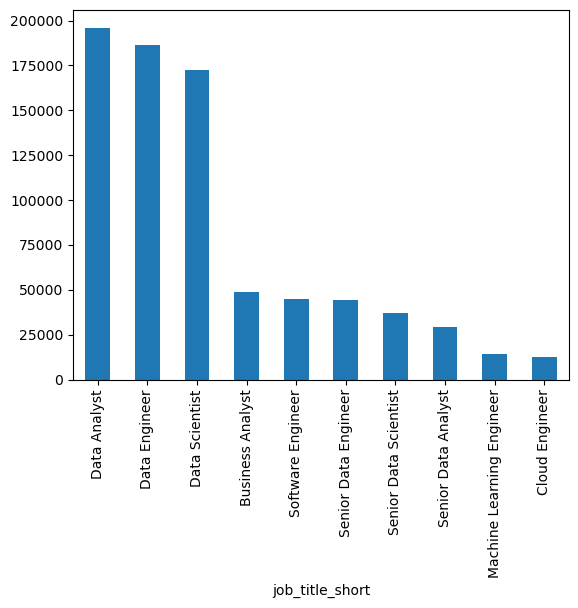

In [2]:
# lets create a simple subplot
fig, ax = plt.subplots()

# plotting the data
df['job_title_short'].value_counts().plot(kind='bar',ax=ax)
plt.show()

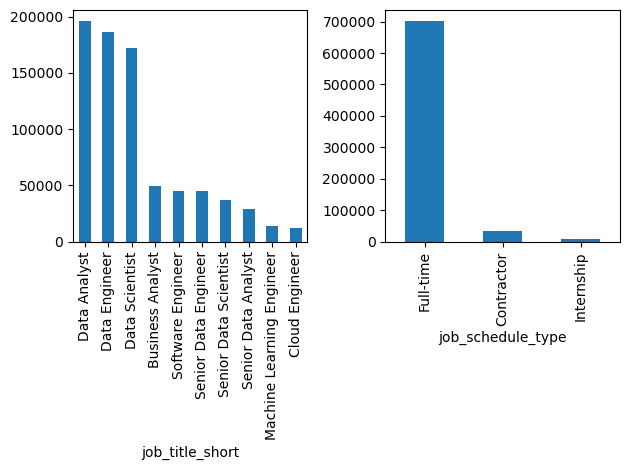

In [8]:
# now lets try plotting 2 graphs
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar',ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar',ax=ax[1])
fig.tight_layout()

In [27]:
# now lets do the same for top skills for different job titles
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skill_count = df_skills.groupby(['job_title_short','job_skills']).size()
df_skill_count = skill_count.reset_index(name='count')
df_skill_count.sort_values(by='count',ascending=False,inplace=True)

In [28]:
df_skill_count

,job_title_short,job_skills,count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


In [39]:
# making a list of job titles
job_titles = df_skill_count['job_title_short'].unique().tolist()
job_titles = job_titles[:3]
job_titles

['Data Scientist', 'Data Engineer', 'Data Analyst']

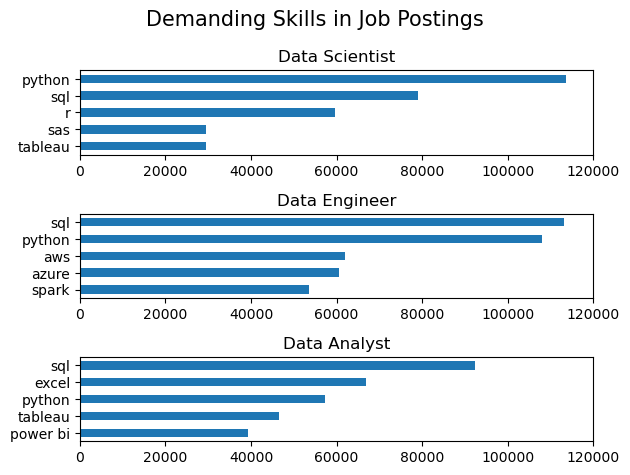

In [53]:
# plotting all graphs combined
from matplotlib.pyplot import suptitle, tight_layout


fig, ax = plt.subplots(len(job_titles),1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_count[df_skill_count['job_title_short']== job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills',y='count',ax=ax[i],title=job_title)
    ax[i].invert_yaxis()
    ax[i].legend().set_visible(False)
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,120000)

# finally the title of the chart
fig.suptitle('Demanding Skills in Job Postings',fontsize=15)

fig.tight_layout()